# Notebook 1 — mRNA gradients → boundary likelihood

Per-pixel **boundary likelihood** from local transcriptional gradients (Tessera-style at transcript resolution).

- **Input:** `transcripts.parquet` for the ROI (`x_um, y_um, gene_id, qv`).
- **Morphology:** DAPI + 18S — used for *visualization context only*, not as input to the gradient estimate.
- **Output (handoff to Python notebook 3):**
    - `boundary_score_per_tx.parquet` — per-transcript score in `[0, 1]`.
    - `boundary_likelihood.tif` — rasterized 2-D map (float32 TIFF), same shape as morphology.
    - The boundary prior (Python side) reads the TIFF and applies it as a per-pixel depth `f` (1 = no-op, 0 = full erase). σ stays a fixed global hyperparameter on the Python side.

This notebook sets up loading + visualization + export. **The gradient estimation itself is a stub** (section 3) — that's what you fill in.

**Stack:** `tiff` (read/write, libtiff direct, no GDAL) + `arrow` (parquet) + `ggplot2` + `dplyr` + `patchwork` + `jsonlite` + `ggnewscale`. Stars/sf were tried but their GDAL backend segfaults on the conda r_env.

## 0. Setup

In [37]:
# install.packages(c("tiff", "arrow", "ggplot2", "dplyr",
#                    "patchwork", "jsonlite", "ggnewscale"))
suppressPackageStartupMessages({
  library(tiff); library(arrow)
  library(ggplot2); library(dplyr); library(patchwork)
  library(jsonlite); library(ggnewscale)
})

DATA_ROOT <- "/Users/ik936/Partners HealthCare Dropbox/Ilya Korsunsky/cellarium/data/Xenium_Prime_Human_Skin_FFPE_xe_outs"
ROI       <- "ROI1"
ROI_DIR   <- file.path(DATA_ROOT, ROI)

## 1. Load ROI data

In [38]:
meta  <- read_json(file.path(ROI_DIR, "metadata.json"), simplifyVector = TRUE)
psize <- meta$pixel_size_um
x0_um <- meta$bbox_um$x0_um; x1_um <- meta$bbox_um$x1_um
y0_um <- meta$bbox_um$y0_um; y1_um <- meta$bbox_um$y1_um
H     <- meta$shape_yx[1]; W <- meta$shape_yx[2]
sprintf("ROI=%s  shape=%dx%d  bbox(µm) x∈[%.0f,%.0f] y∈[%.0f,%.0f]  pix=%.4f µm",
        ROI, H, W, x0_um, x1_um, y0_um, y1_um, psize)

[1] "ROI=ROI1  shape=612x1223  bbox(µm) x∈[960,1220] y∈[2930,3060]  pix=0.2125 µm"

In [39]:
# Load TIFFs as plain matrices via libtiff (avoids the GDAL segfault path).
# `as.is = TRUE` keeps the raw uint16 values. Shape: (H, W) row x col.
m_dapi <- readTIFF(file.path(ROI_DIR, "morphology_DAPI.tif"), as.is = TRUE)
m_s18  <- readTIFF(file.path(ROI_DIR, "morphology_18S.tif"),  as.is = TRUE)
cat(sprintf("DAPI: %dx%d  range=[%d, %d]\n", nrow(m_dapi), ncol(m_dapi),
            min(m_dapi), max(m_dapi)))
cat(sprintf("18S:  %dx%d  range=[%d, %d]\n", nrow(m_s18),  ncol(m_s18),
            min(m_s18),  max(m_s18)))

DAPI: 612x1223  range=[0, 5070]
18S:  612x1223  range=[0, 4071]


In [40]:
df_tx <- read_parquet(file.path(ROI_DIR, "transcripts.parquet"))

# gene_id → gene_name from the panel JSON (gene_id is 1-indexed into payload$targets)
panel    <- read_json(file.path(DATA_ROOT, "gene_panel.json"), simplifyVector = TRUE)
gene_map <- vapply(panel$payload$targets$type$data$name, identity, character(1))
df_tx$gene <- gene_map[df_tx$gene_id]

cat(sprintf("transcripts: %d  unique genes: %d\n", nrow(df_tx), n_distinct(df_tx$gene)))
glimpse(df_tx)

transcripts: 51388  unique genes: 3583
Rows: 51,388
Columns: 6
$ x_um    <dbl> 976.3594, 966.1875, 960.0781, 961.4062, 976.6562, 976.1094, 96…
$ y_um    <dbl> 2945.031, 2982.266, 2944.672, 2949.656, 2966.922, 2967.172, 29…
$ z_um    <dbl> 28.37500, 29.79688, 30.60938, 30.17188, 29.51562, 29.67188, 30…
$ gene_id <int> 1, 1, 1, 3, 3, 3, 4, 5, 5, 5, 5, 5, 5, 12, 12, 21, 30, 30, 31,…
$ qv      <dbl> 29.75, 40.00, 21.75, 26.50, 28.00, 40.00, 40.00, 40.00, 31.00,…
$ gene    <chr> "A2ML1", "A2ML1", "A2ML1", "AAR2", "AAR2", "AAR2", "AARSD1", "…


## 2. Visualize baseline (morphology + transcripts)

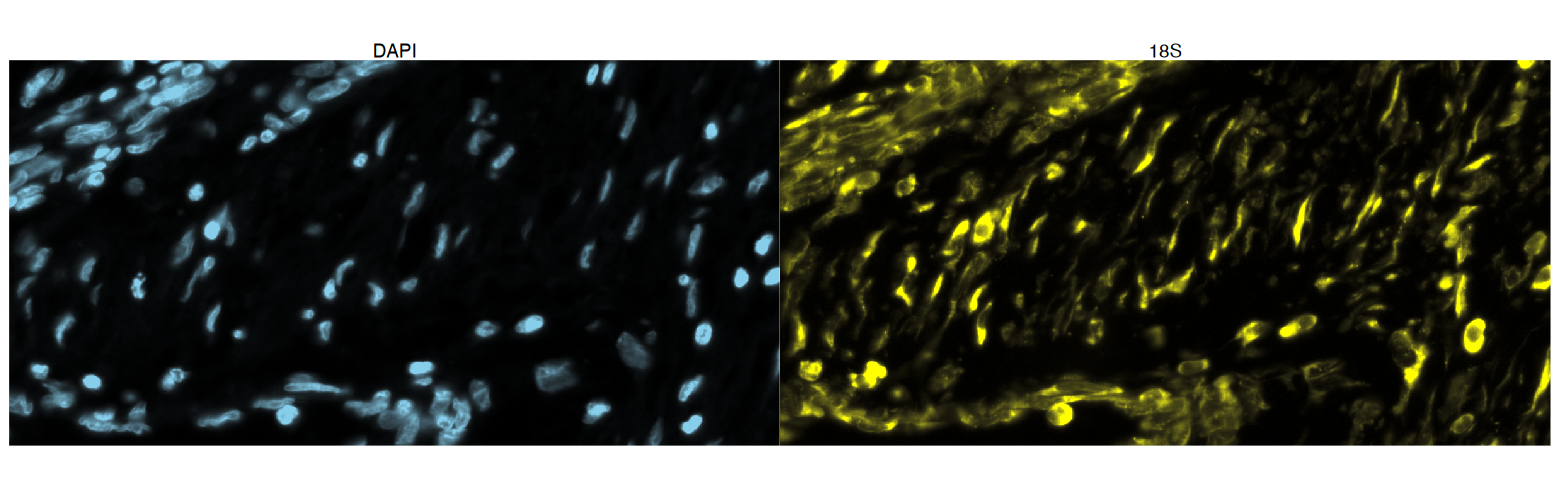

In [41]:
# ─── Helpers ─────────────────────────────────────────────────────────────
norm01 <- function(v, low = 0.01, high = 0.99) {
  # pmin/pmax drop matrix attributes — use indexed assignment so dim is preserved.
  q <- quantile(as.numeric(v), c(low, high), na.rm = TRUE)
  out <- (v - q[1]) / max(diff(q), 1e-6)
  out[!is.na(out) & out < 0] <- 0
  out[!is.na(out) & out > 1] <- 1
  out
}

# Build long-format (x, y, v) df from a matrix in image-coord row-major.
# Convention: row 1 of the matrix = image's top row = y_um nearest y0_um (the
# *lower* µm bound). Pixel center: x_um = x0_um + (col - 0.5)*psize, similarly y.
# Each transcript at its (x_um, y_um) lands on the corresponding tile by construction.
mat_to_df <- function(m) {
  Hm <- nrow(m); Wm <- ncol(m)
  df <- expand.grid(row = seq_len(Hm), col = seq_len(Wm))
  df$v <- as.vector(m)
  df$x <- x0_um + (df$col - 0.5) * psize
  df$y <- y0_um + (df$row - 0.5) * psize
  df[, c("x", "y", "v")]
}

# Build morphology dfs ONCE — these are reused across all morphology plots.
# 612×1223 ≈ 750k rows each; ~1 s per df, ~17 MB. Trades a small one-time build
# cost for unambiguous coordinate alignment (vs annotation_raster, whose y-axis
# interaction with reversed limits/scale is fragile).
df_dapi <- mat_to_df(norm01(m_dapi))
df_s18  <- mat_to_df(norm01(m_s18))

# show_morph: render a pre-built morphology df. Y-axis is reversed via coord_fixed's
# ylim = c(y1_um, y0_um) — image-coord convention (low y_um at top of plot), which
# also matches the transcripts' y_um (so geom_point overlays align tile-for-tile).
show_morph <- function(df, color = "white", title = "") {
  ggplot(df, aes(x = x, y = y, fill = v)) +
    geom_raster() +
    scale_fill_gradient(low = "black", high = color, na.value = "black", guide = "none") +
    coord_fixed(xlim = c(x0_um, x1_um), ylim = c(y1_um, y0_um), expand = FALSE) +
    theme_void() +
    theme(plot.title = element_text(hjust = 0.5, size = 11)) +
    labs(title = title)
}

options(repr.plot.width = 13, repr.plot.height = 4.0)
(show_morph(df_dapi, "skyblue", "DAPI") | show_morph(df_s18, "yellow", "18S"))

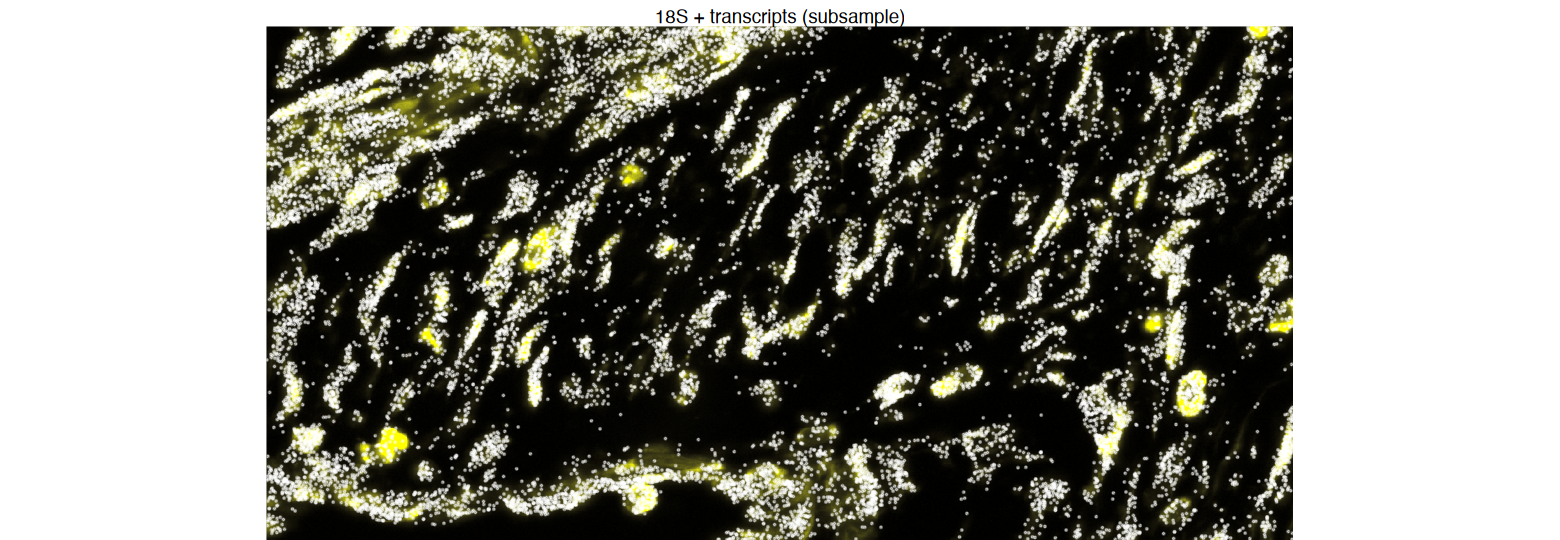

In [42]:
# Subsample transcripts for plotting speed (gradient code in section 3 should use full df_tx)
tx_sample <- df_tx |> slice_sample(n = min(20000, nrow(df_tx)))

options(repr.plot.width = 13, repr.plot.height = 4.5)
show_morph(df_s18, "yellow", "18S + transcripts (subsample)") +
  geom_point(data = tx_sample, aes(x = x_um, y = y_um),
             color = "white", size = 0.05, alpha = 0.45,
             inherit.aes = FALSE)

## 3. mRNA gradients → per-transcript boundary score

Plan:
1. **3.1** Load `gene_celltype_counts_{level}.parquet` from notebook 02 (raw counts per gene × cell type). Build per-gene embedding by column-normalizing (P(gene | type), columns sum to 1) then z-scoring each gene's row across types. `level` ∈ {`lineage`, `fine`}.
2. **3.2** Load per-gene lineage labels from notebook 02 (`gene_labels_lineage.parquet`), attach to transcripts. Show **before / after** plots of the ambiguous filter so the effect is visible. No filter logic here — that's decided in notebook 02 §5e.
3. **3.3** Tessera: Delaunay mesh with 3 µm edge cutoff → gradient field on the embedding → anisotropic smoothing → per-transcript gradient magnitude as the boundary score.
4. **3.4** Visualize the gradient field over DAPI + 18S.

Notebook 02 must have been run first to produce `gene_celltype_counts_{fine,lineage}.parquet` + `gene_labels_lineage.parquet`.

### 3.1 Load gene × cell-type counts → build per-gene embedding

Notebook 02 exports raw counts (`gene_celltype_counts_*.parquet`). We normalize here on-the-fly:

1. **Column-normalize** so each cell-type column sums to 1 → `P(gene | type)`. Why: row-normalizing counts (P(type | gene)) would bias every gene toward the most populous class — in this melanoma sample ~54% of cells are Melanoma, so any gene at all would look "Melanoma-specific" even when it isn't.
2. **Z-score each gene's row** (mean = 0, sd = 1 across types). The result is a centered K-dim vector per gene that encodes *relative enrichment across types*, regardless of overall expression level. This is the embedding we feed to SVD/PCA without any further centering or scaling.

Default `LEVEL = "lineage"` (7 types). Switch to `"fine"` (15 types) if you want gradients sensitive to within-lineage transitions.

In [43]:
LEVEL <- "lineage"     # or "fine"

counts_long <- arrow::read_parquet(
  file.path(DATA_ROOT, sprintf("gene_celltype_counts_%s.parquet", LEVEL)))
counts_wide <- tidyr::pivot_wider(counts_long, names_from = cell_type,
                                   values_from = count, values_fill = 0)
cell_type_cols <- setdiff(colnames(counts_wide), "gene")
K              <- length(cell_type_cols)

counts_mat <- as.matrix(counts_wide[, cell_type_cols])
rownames(counts_mat) <- counts_wide$gene

# (1) Column-normalize — P(gene | type), columns sum to 1
col_sums    <- pmax(colSums(counts_mat), 1)
p_g_given_t <- sweep(counts_mat, 2, col_sums, "/")

# (2) Z-score each gene's row (across types). Constant rows → all zeros.
zscore_row <- function(x) {
  m <- mean(x); s <- sd(x)
  if (is.na(s) || s < 1e-12) return(rep(0, length(x)))
  (x - m) / s
}
emb_mat_by_gene <- t(apply(p_g_given_t, 1, zscore_row))
colnames(emb_mat_by_gene) <- cell_type_cols

# Long-format for joining transcripts to their gene's embedding
g2t_wide <- as.data.frame(emb_mat_by_gene)
g2t_wide$gene <- rownames(emb_mat_by_gene)
g2t_wide <- g2t_wide[, c("gene", cell_type_cols)]

cat(sprintf("%d genes × %d cell types   (loaded from gene_celltype_counts_%s.parquet)\n",
            nrow(g2t_wide), K, LEVEL))

# Sanity: every row should have mean ~0, sd ~1 (or all-zero if constant)
row_means <- rowMeans(emb_mat_by_gene)
row_sds   <- apply(emb_mat_by_gene, 1, sd)
cat(sprintf("row-mean range: [%.4g, %.4g]   row-sd range: [%.4g, %.4g]\n",
            min(row_means), max(row_means), min(row_sds), max(row_sds)))
head(g2t_wide, 3)

5006 genes × 7 cell types   (loaded from gene_celltype_counts_lineage.parquet)
row-mean range: [-8.406e-16, 9.168e-16]   row-sd range: [1, 1]


,gene,Endothelial,Fibroblast,Keratinocyte,Melanoma,Myeloid,Plasma,Tcell
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2ML1,A2ML1,-0.3784521,-0.3779415,2.2677867,-0.3779321,-0.3775861,-0.37742274,-0.3784521
AAMP,AAMP,-0.8557201,-0.9444783,0.5740811,1.9519441,-0.2846945,-0.05071421,-0.3904181
AAR2,AAR2,1.9582589,0.1316389,-0.2340168,0.3004860,-0.9230595,-1.05839736,-0.1749101


### 3.2 Attach lineage labels (from notebook 02), filter, plot

Notebook 02 §5e decided every gene's label (one of the 7 lineages or `"ambiguous"`). Here we just consume that decision: join labels to transcripts, drop ambiguous ones, plot the rest colored by lineage. No filter logic in this notebook.

Two views: **before** (all transcripts of labeled-or-ambiguous genes) and **after** (only transcripts of cleanly-labeled genes), so you can see the effect of the filter.

In [44]:
# Load per-gene lineage labels from notebook 02
gene_labels <- arrow::read_parquet(file.path(DATA_ROOT, "gene_labels_lineage.parquet"))
cat("Per-gene label distribution (from notebook 02):\n")
print(sort(table(gene_labels$label), decreasing = TRUE))

Per-gene label distribution (from notebook 02):

   ambiguous Keratinocyte  Endothelial        Tcell       Plasma      Myeloid 
        4327          239          141           89           79           51 
  Fibroblast     Melanoma 
          41           39 


In [45]:
# Attach labels to transcripts (drops controls etc. that aren't in the panel)
tx_labeled <- df_tx |>
  select(x_um, y_um, gene, qv) |>
  inner_join(gene_labels, by = "gene")

cat(sprintf("\nTranscripts after gene-filter: %d of %d (%.1f%%)\n",
            nrow(tx_labeled), nrow(df_tx),
            100 * nrow(tx_labeled) / nrow(df_tx)))
cat("\nTranscripts per label:\n")
print(sort(table(tx_labeled$label), decreasing = TRUE))

# Also keep the z-scored embedding for downstream gradient computation in §3.3
tx_emb <- df_tx |>
  select(x_um, y_um, gene, qv) |>
  inner_join(g2t_wide, by = "gene")
emb_mat <- as.matrix(tx_emb[, cell_type_cols])


Transcripts after gene-filter: 51341 of 51388 (99.9%)

Transcripts per label:

   ambiguous Keratinocyte  Endothelial       Plasma        Tcell      Myeloid 
       45060         2413         1259          762          748          393 
  Fibroblast     Melanoma 
         374          332 


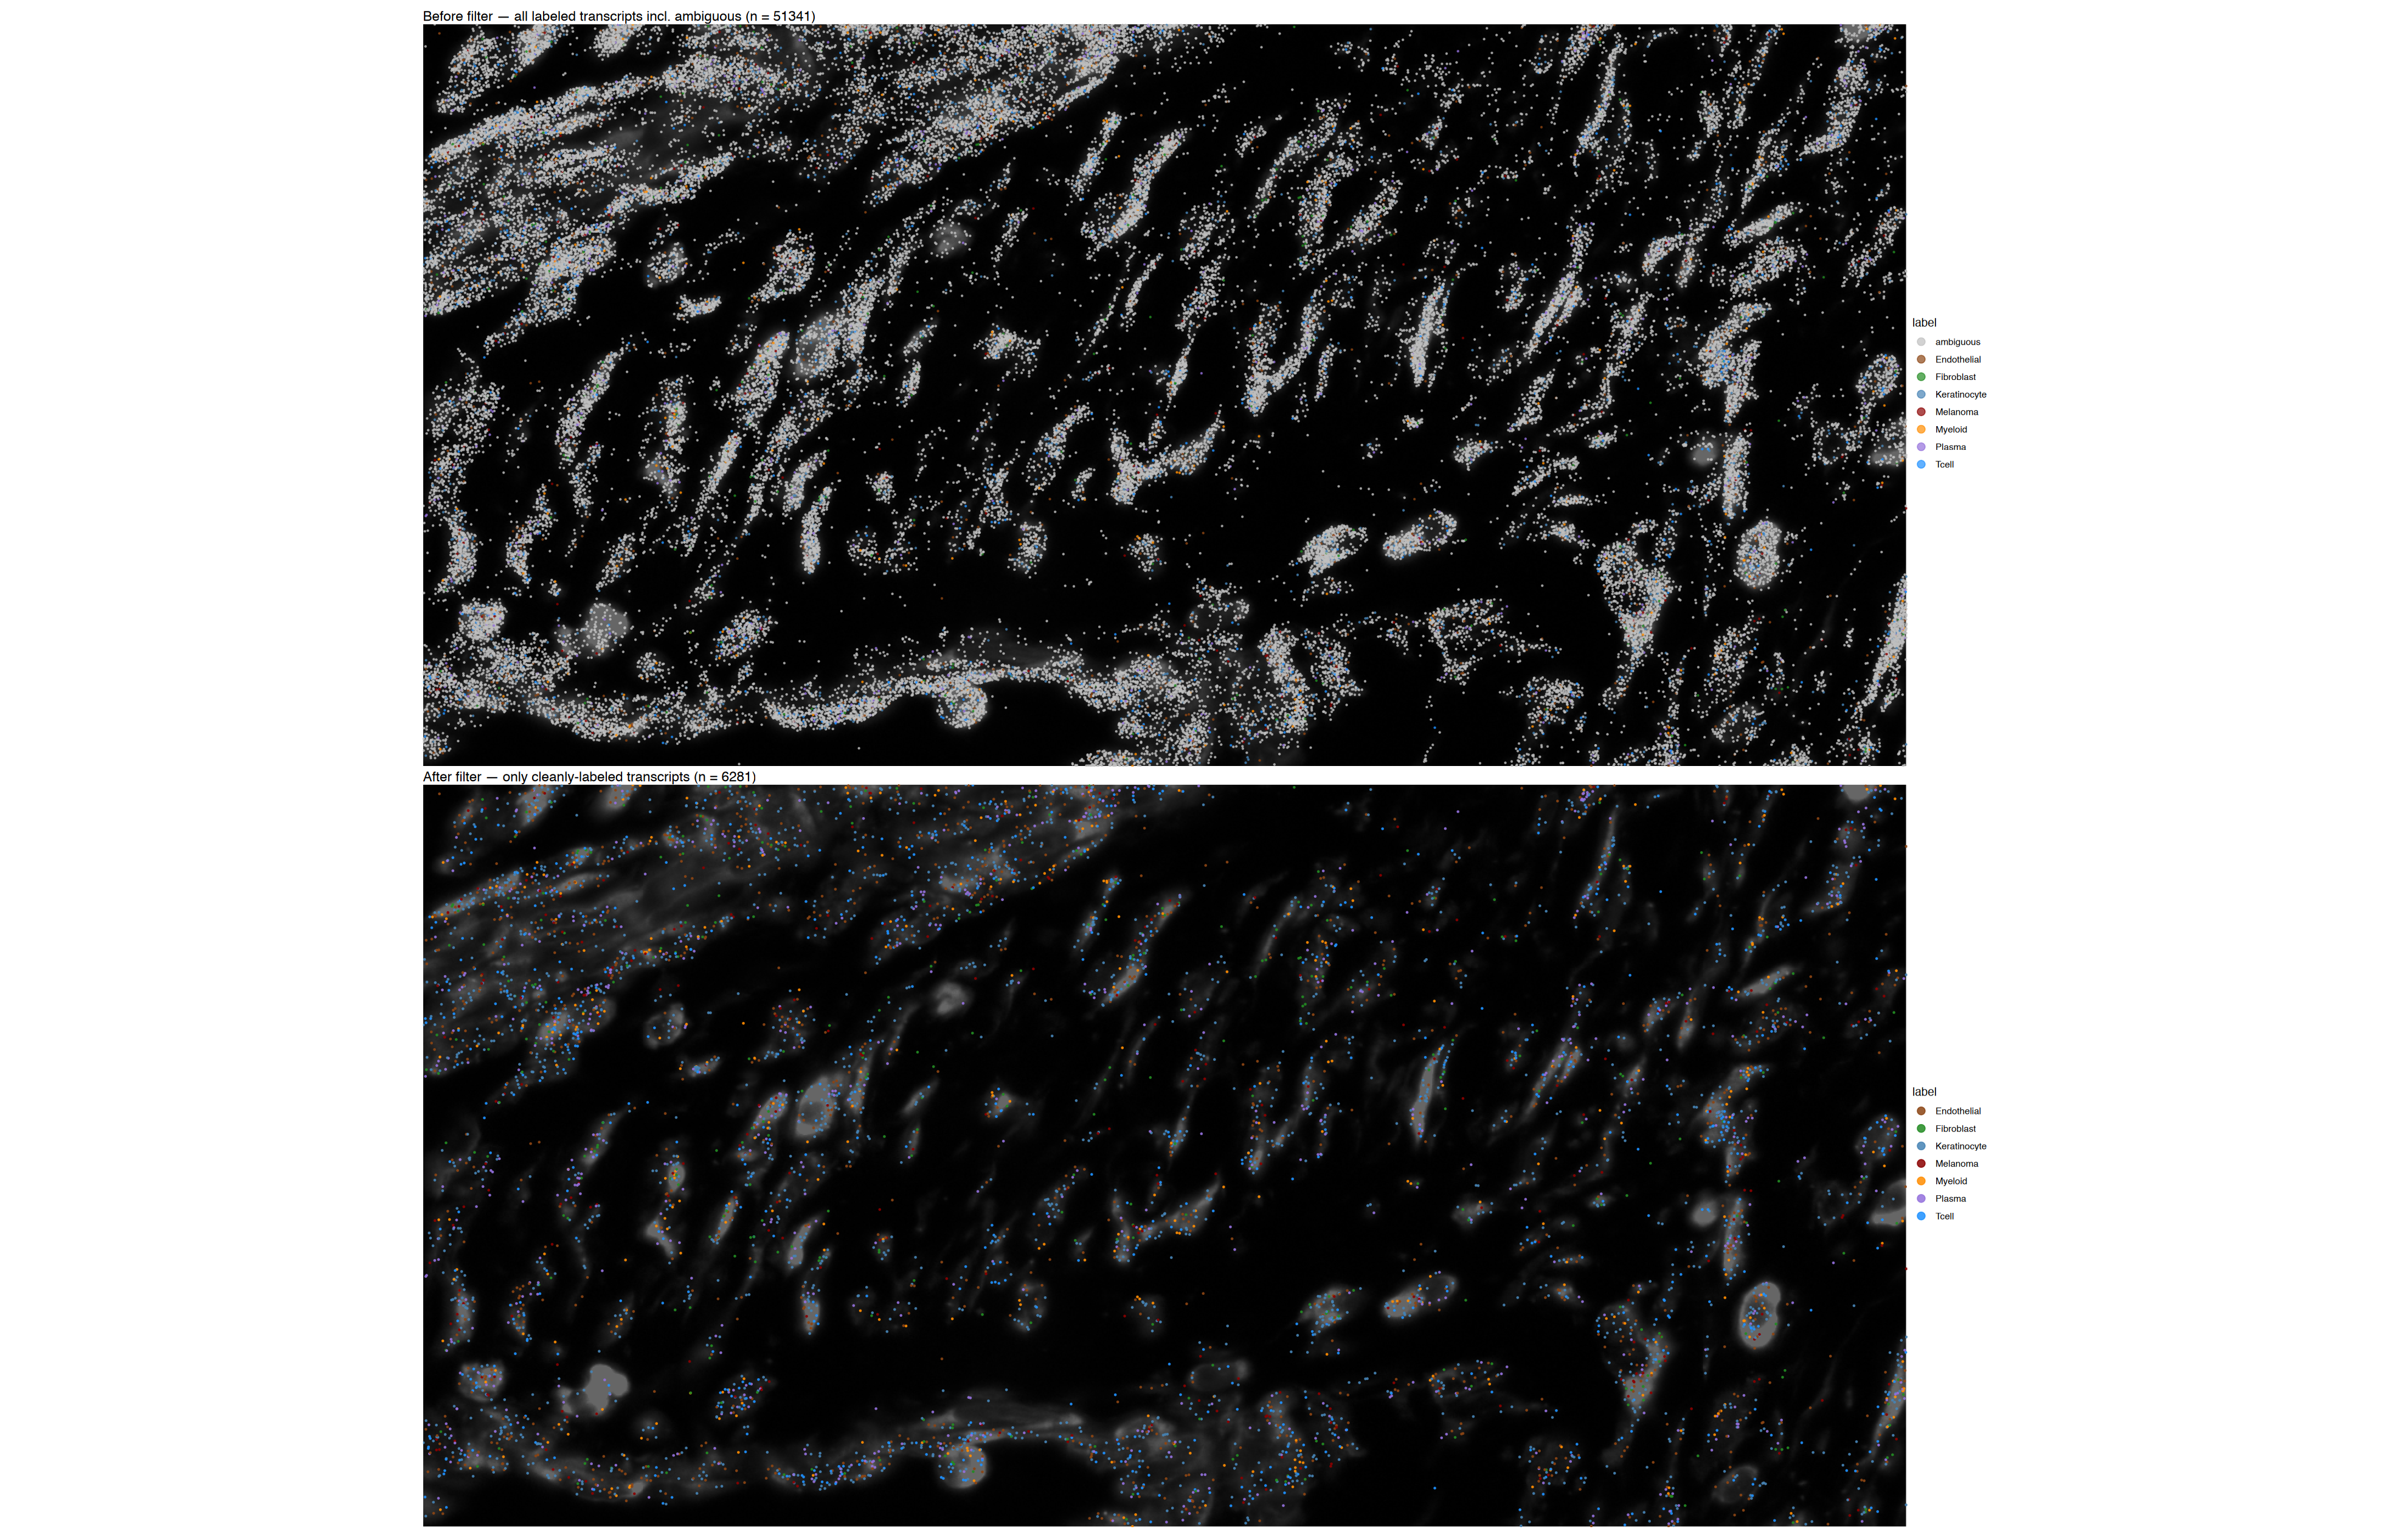

In [49]:
# Lineage color palette (matches notebook 02 §5c). Ambiguous = grey.
lineage_colors <- c(
  "Melanoma"     = "#8B0000",
  "Myeloid"      = "#FF8C00",
  "Tcell"        = "#1E90FF",
  "Plasma"       = "#9370DB",
  "Fibroblast"   = "#228B22",
  "Endothelial"  = "#8B4513",
  "Keratinocyte" = "#4682B4",
  "ambiguous"    = "grey75"
)

# Subsample for plotting speed if needed (full df_tx is ~50k transcripts)
plot_full <- tx_labeled |> slice_sample(n = min(80000, nrow(tx_labeled)))
plot_kept <- tx_labeled |> filter(label != "ambiguous") |>
  slice_sample(n = min(80000, sum(tx_labeled$label != "ambiguous")))

p_before <- ggplot() +
  geom_raster(data = df_s18, aes(x = x, y = y, fill = v)) +
  scale_fill_gradient(low = "black", high = "gray40", na.value = "black", guide = "none") +
  geom_point(data = plot_full, aes(x = x_um, y = y_um, color = label),
             size = 0.18, alpha = 0.7) +
  scale_color_manual(values = lineage_colors, name = "label",
                     na.value = "grey50") +
  guides(color = guide_legend(override.aes = list(size = 3))) +
  coord_fixed(xlim = c(x0_um, x1_um), ylim = c(y1_um, y0_um), expand = FALSE) +
  theme_void() +
  labs(title = sprintf("Before filter — all labeled transcripts incl. ambiguous (n = %d)",
                        nrow(tx_labeled)))

p_after <- ggplot() +
  geom_raster(data = df_s18, aes(x = x, y = y, fill = v)) +
  scale_fill_gradient(low = "black", high = "gray40", na.value = "black", guide = "none") +
  geom_point(data = plot_kept, aes(x = x_um, y = y_um, color = label),
             size = 0.25, alpha = 0.85) +
  scale_color_manual(values = lineage_colors, name = "label",
                     na.value = "grey50") +
  guides(color = guide_legend(override.aes = list(size = 3))) +
  coord_fixed(xlim = c(x0_um, x1_um), ylim = c(y1_um, y0_um), expand = FALSE) +
  theme_void() +
  labs(title = sprintf("After filter — only cleanly-labeled transcripts (n = %d)",
                        sum(tx_labeled$label != "ambiguous")))

options(repr.plot.width = 33, repr.plot.height = 21)
p_before / p_after

### 3.3 Tessera mesh + gradient + anisotropic smoothing

`tessera::make_mesh` builds the Delaunay graph and applies the edge-length cutoff (3 µm); `estimate_field` computes a gradient vector field on the embedding; `smooth_field` does anisotropic smoothing (bilateral with euclidean distance + similarity).

Output shape of `estimate_field` / `smooth_field` is `(2, K, N)` — (xy direction × embed dim × points). Per-point gradient magnitude = `sqrt(sum_squared over dims 1 and 2)`.

**Note on scale:** ~50k transcripts in ROI1; mesh + field should take well under a minute. For multi-ROI / whole-slide work, batch by ROI.

In [47]:
suppressPackageStartupMessages(library(tessera))

# Tessera's pipeline expects a counts matrix to live alongside the cells; we
# don't need it for the field (we provide our own embedding), so pass a thin
# placeholder. mesh_meta is also required, so wrap a single-group factor.
coords_all <- as.matrix(tx_emb[, c("x_um", "y_um")])
n_tx       <- nrow(coords_all)
placeholder_counts <- Matrix::sparseMatrix(integer(0), integer(0), dims = c(0, n_tx))
mesh_meta  <- data.table::data.table(grp = factor(rep(1, n_tx)))

cells_t <- tessera::make_cells(coords_all, NULL, placeholder_counts, mesh_meta)

PRUNE_UM <- 3.0
mesh_t   <- tessera::make_mesh(cells_t, list(prune_thresh = PRUNE_UM))
keep_idx <- as.integer(mesh_t$pts$ORIG_ID)
cat(sprintf("mesh: kept %d of %d transcripts (prune_thresh = %g µm)   edges: %d\n",
            length(keep_idx), n_tx, PRUNE_UM, nrow(mesh_t$edges)))

emb_kept <- emb_mat[keep_idx, , drop = FALSE]
pts_kept <- as.matrix(mesh_t$pts[, c("X", "Y")])

'as(<ngCMatrix>, "dgCMatrix")' is deprecated.
Use 'as(., "dMatrix")' instead.
See help("Deprecated") and help("Matrix-deprecated").

Warning message in geometry::delaunayn(pts):
“30 points missing from triangulation.
It is possible that setting the 'options' argument of delaunayn may help.
For example:
options = "Qt Qc Qz Qbb"
options = "Qt Qc Qz QbB"
If these options do not work, try shifting the centre of the points
to the origin by subtracting the mean coordinates from every point.”


mesh: kept 50967 of 51341 transcripts (prune_thresh = 3 µm)   edges: 148967


In [48]:
t0 <- Sys.time()
field_raw    <- tessera::estimate_field(pts_kept, mesh_t$adj, emb_kept)
field_smooth <- tessera::smooth_field(pts_kept, field_raw, mesh_t$adj,
                                       distance = "euclidean", similarity = "euclidean")
cat(sprintf("Tessera field: %.1f s   field shape: %s\n",
            as.numeric(difftime(Sys.time(), t0, units = "secs")),
            paste(dim(field_smooth), collapse = " × ")))

# Per-point gradient magnitude over the embedding
grad_mag_kept <- sqrt(apply(field_smooth^2, 3, sum))

# Map back to all transcripts (kept-only points have a magnitude; pruned-out get NA)
df_tx_emb <- tx_emb
df_tx_emb$boundary_score <- NA_real_
df_tx_emb$boundary_score[keep_idx] <- grad_mag_kept

# Normalize to [0, 1] by 99th percentile (robust to outliers)
q99 <- quantile(df_tx_emb$boundary_score, 0.99, na.rm = TRUE)
df_tx_emb$boundary_score <- pmin(1, df_tx_emb$boundary_score / max(q99, 1e-6))
cat(sprintf("boundary_score range: [%.3f, %.3f]   q99 = %.3f\n",
            min(df_tx_emb$boundary_score, na.rm = TRUE),
            max(df_tx_emb$boundary_score, na.rm = TRUE),
            q99))

Tessera field: 0.4 s   field shape: 2 × 7 × 50967
boundary_score range: [0.119, 1.000]   q99 = 1.448


### 3.4 Visualize gradient over DAPI + 18S

In [ ]:
options(repr.plot.width = 13, repr.plot.height = 5.5)
ggplot() +
  geom_raster(data = df_s18, aes(x = x, y = y, fill = v)) +
  scale_fill_gradient(low = "black", high = "gray70", na.value = "black", guide = "none") +
  geom_point(data = df_tx_emb |> filter(!is.na(boundary_score)),
             aes(x = x_um, y = y_um, color = boundary_score),
             size = 0.18, alpha = 0.8) +
  scale_color_viridis_c(option = "magma", limits = c(0, 1), name = "boundary\nscore") +
  coord_fixed(xlim = c(x0_um, x1_um), ylim = c(y1_um, y0_um), expand = FALSE) +
  theme_void() +
  labs(title = "Smoothed mRNA-gradient magnitude over 18S")

In [ ]:
# Push the boundary scores back onto df_tx (NA for transcripts dropped at the
# gene-filter or mesh-prune stages — those become "no evidence" pixels later).
df_tx$boundary_score <- NA_real_
match_idx <- match(paste(df_tx$x_um, df_tx$y_um, df_tx$gene),
                   paste(df_tx_emb$x_um, df_tx_emb$y_um, df_tx_emb$gene))
df_tx$boundary_score <- df_tx_emb$boundary_score[match_idx]
cat(sprintf("df_tx$boundary_score: %d non-NA of %d (%.1f%%)\n",
            sum(!is.na(df_tx$boundary_score)), nrow(df_tx),
            100 * mean(!is.na(df_tx$boundary_score))))

## 4. Score → mask — YOUR CODE GOES HERE

Convert per-transcript `df_tx$boundary_score` (high = strong boundary, in [0, 1]) into a **per-pixel `boundary_likelihood`** matrix where:
- `0` = full erase (deep cut)
- `1` = no-op (no cut)

So the mapping goes in the opposite direction from the score: high boundary score → low likelihood value. Whatever transformation you design (thresholding, sigmoid, smoothing, dilation around strong-evidence pixels, ...) goes here.

**Default fallback** (the next cell): rasterize per-transcript scores to per-pixel via simple mean, then invert (`1 - normalize`). This is just a placeholder — override `boundary_likelihood` in your own cell before §5 if you have something smarter.

In [ ]:
# ─── YOUR CODE HERE ─────────────────────────────────────────────────
# Produce `boundary_likelihood` — H × W numeric matrix in [0, 1].
# 1 = no-op (no cut), 0 = full erase (deep cut).
#
# Leave `boundary_likelihood <- NULL` to use the default fallback below.

boundary_likelihood <- NULL
# ────────────────────────────────────────────────────────────────────

### 4-fallback. Default rasterization

Runs only if §4 above didn't produce `boundary_likelihood`. Mean of per-tx scores within each pixel bin, then inverted so high boundary score → low likelihood (deep cut).

In [ ]:
if (is.null(boundary_likelihood)) {
  # Map (x_um, y_um) → (col, row) integer pixel indices
  col <- pmin(W, pmax(1, floor((df_tx$x_um - x0_um) / psize) + 1L))
  row <- pmin(H, pmax(1, floor((df_tx$y_um - y0_um) / psize) + 1L))

  # Per-pixel mean of per-transcript boundary scores
  agg <- tapply(df_tx$boundary_score, list(row, col), mean, na.rm = TRUE)
  agg_mat <- matrix(NA_real_, nrow = H, ncol = W)
  agg_mat[as.integer(rownames(agg)), as.integer(colnames(agg))] <- agg

  # Invert: high boundary score → low multiplier (deep cut)
  # NA pixels (no transcripts) → 1.0 (no-op)
  boundary_likelihood <- 1.0 - agg_mat
  boundary_likelihood[is.na(boundary_likelihood)] <- 1.0
  boundary_likelihood[boundary_likelihood < 0] <- 0
  boundary_likelihood[boundary_likelihood > 1] <- 1
}
cat(sprintf("boundary_likelihood: %dx%d   range=[%.3f, %.3f]   no-op pixels=%.1f%%\n",
            nrow(boundary_likelihood), ncol(boundary_likelihood),
            min(boundary_likelihood), max(boundary_likelihood),
            100 * mean(boundary_likelihood >= 0.999)))

## 5. Visualize gradient on morphology

In [ ]:
# Long-format df for the gradient layer (drop NA pixels so they show as transparent).
grad_df <- mat_to_df(boundary_likelihood)
grad_df <- grad_df[!is.na(grad_df$v), , drop = FALSE]

# Side-by-side: morphology | gradient (raw)
p_morph <- show_morph(df_s18, "yellow", "18S")
p_grad  <- ggplot() +
  geom_raster(data = grad_df, aes(x = x, y = y, fill = v)) +
  scale_fill_viridis_c(option = "magma", limits = c(0, 1),
                       na.value = "transparent", name = "boundary\nscore") +
  coord_fixed(xlim = c(x0_um, x1_um), ylim = c(y1_um, y0_um), expand = FALSE) +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5, size = 11)) +
  labs(title = "boundary likelihood")

options(repr.plot.width = 13, repr.plot.height = 4.5)
(p_morph | p_grad)

In [ ]:
# Overlay: morphology background (geom_raster, gray) + gradient layer (geom_raster,
# magma fill). ggnewscale lets us use two different fill scales in one plot.
options(repr.plot.width = 13, repr.plot.height = 5.5)
ggplot() +
  geom_raster(data = df_s18, aes(x = x, y = y, fill = v)) +
  scale_fill_gradient(low = "black", high = "gray80", na.value = "black", guide = "none") +
  new_scale_fill() +
  geom_raster(data = grad_df, aes(x = x, y = y, fill = v), alpha = 0.6) +
  scale_fill_viridis_c(option = "magma", limits = c(0, 1),
                       na.value = "transparent", name = "boundary") +
  coord_fixed(xlim = c(x0_um, x1_um), ylim = c(y1_um, y0_um), expand = FALSE) +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5, size = 11)) +
  labs(title = "18S (background) + boundary-likelihood overlay")

## 6. Export for Python notebook 3

In [ ]:
out_dir <- file.path(ROI_DIR, "boundary_prior")
dir.create(out_dir, showWarnings = FALSE)

# Per-transcript scores
df_tx |>
  select(x_um, y_um, gene, qv, boundary_score) |>
  write_parquet(file.path(out_dir, "boundary_score_per_tx.parquet"))

# Rasterized 2-D boundary likelihood as a uint16 TIFF.
# Why uint16 and not float32: `tiff::writeTIFF` only emits *integer* TIFFs
# (bits.per.sample 8/16/32 all integer). float32 isn't an option in this
# package. Using uint16 — scaling in R is automatic when the input is in
# [0, 1] (writeTIFF maps [0,1] → [0, 65535]).
#
# >>> PYTHON HANDOFF: divide by 65535 after `tifffile.imread` to recover
# >>> the [0, 1] f-value. NA pixels in R are encoded as 1.0 (no-op).
to_write <- boundary_likelihood
to_write[is.na(to_write)] <- 1.0   # NA → no-op (no boundary evidence here)
to_write[to_write < 0]    <- 0     # safety clip
to_write[to_write > 1]    <- 1
writeTIFF(to_write, file.path(out_dir, "boundary_likelihood.tif"),
          bits.per.sample = 16L)

cat(sprintf("wrote:\n  %s\n  %s\n",
            file.path(out_dir, "boundary_score_per_tx.parquet"),
            file.path(out_dir, "boundary_likelihood.tif")))

---

**Handoff format (locked):**

| File | Format | Per-pixel? | Notes |
|---|---|---|---|
| `boundary_score_per_tx.parquet` | parquet | no | `(x_um, y_um, gene, qv, boundary_score)` |
| `boundary_likelihood.tif` | uint16 TIFF (1-band) | yes | shape = morphology shape; **values pre-scaled by 65535** — Python side does `tifffile.imread(...) / 65535.0` to recover `f ∈ [0, 1]`. NA pixels (no transcripts in pixel) written as `1.0` → uint16 `65535` → no-op on the Python side. |

Python notebook 3 reads `boundary_likelihood.tif` and applies it as a per-pixel depth `f` in the gap-cut intervention (1 = no-op, 0 = full erase). σ stays a fixed global hyperparameter on the Python side.

## 7. Round-trip through cpsam — test the boundary mask in-loop

Iterate fast without leaving the notebook: build modified 18S in R → write input TIFFs → call cpsam via `system2()` against the omnipose env's python → read back masks + cellprob + flow magnitude → visualize alongside the morphology.

`scripts/run_cpsam_on_dir.py` runs cpsam with the validated max-recall config (`cellprob=-5, flow=0, augment=True, niter=200`) and writes:
- `masks.tif` — uint16 label image
- `cellprob.tif` + `flow_mag.tif` — uint16 with linear scaling
- `scaling.json` — `scale` / `offset` to recover the original float values

### 7a. Build modified 18S

In [ ]:
# Apply boundary_likelihood as a multiplicative mask on 18S.
# NA pixels (no transcripts) → 1.0 = no-op.
bl <- boundary_likelihood
bl[is.na(bl)] <- 1.0
s18_modified <- m_s18 * bl

# Side-by-side: original vs modified 18S
df_s18_mod <- mat_to_df(norm01(s18_modified))

options(repr.plot.width = 13, repr.plot.height = 4.0)
p_orig <- show_morph(df_s18,     "yellow", "original 18S")
p_mod  <- ggplot(df_s18_mod, aes(x = x, y = y, fill = v)) +
  geom_raster() +
  scale_fill_gradient(low = "black", high = "yellow", na.value = "black", guide = "none") +
  coord_fixed(xlim = c(x0_um, x1_um), ylim = c(y1_um, y0_um), expand = FALSE) +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5, size = 11)) +
  labs(title = "modified 18S (× boundary_likelihood)")
(p_orig | p_mod)

### 7b. Save inputs as uint16 TIFFs (writeTIFF expects [0, 1])

In [ ]:
rt_dir <- file.path(ROI_DIR, "cpsam_roundtrip")
dir.create(rt_dir, showWarnings = FALSE)

# Normalize so writeTIFF auto-scales to [0, 65535]. m_dapi/m_s18 are uint16 from
# tiff::readTIFF(as.is=TRUE), so divide by their max.
writeTIFF(m_dapi       / max(m_dapi), file.path(rt_dir, "dapi.tif"), bits.per.sample = 16L)
writeTIFF(s18_modified / max(m_s18),  file.path(rt_dir, "s18.tif"),  bits.per.sample = 16L)
cat(sprintf("wrote: %s/{dapi,s18}.tif\n", rt_dir))

### 7c. Call cpsam via system2 (omnipose env's python)

Takes ~30–60 s on ROI1 with augment=True. Output streams below.

In [ ]:
PY     <- "/Users/ik936/miniconda3/envs/omnipose/bin/python"
SCRIPT <- "/Users/ik936/Partners HealthCare Dropbox/Ilya Korsunsky/cellarium/scripts/run_cpsam_on_dir.py"

t0 <- Sys.time()
log <- system2(PY, args = c(shQuote(SCRIPT), shQuote(rt_dir), shQuote(rt_dir)),
               stdout = TRUE, stderr = TRUE)
cat(log, sep = "\n")
cat(sprintf("\n--- cpsam round-trip took %.1f s ---\n",
            as.numeric(difftime(Sys.time(), t0, units = "secs"))))

### 7d. Read outputs back into R

In [ ]:
masks   <- readTIFF(file.path(rt_dir, "masks.tif"), as.is = TRUE)
scaling <- read_json(file.path(rt_dir, "scaling.json"))

cprob_u16 <- readTIFF(file.path(rt_dir, "cellprob.tif"), as.is = TRUE)
cellprob  <- cprob_u16 * scaling$cellprob$scale + scaling$cellprob$offset

flow_u16  <- readTIFF(file.path(rt_dir, "flow_mag.tif"), as.is = TRUE)
flow_mag  <- flow_u16  * scaling$flow_mag$scale + scaling$flow_mag$offset

cat(sprintf("n cells: %d   cellprob range: [%.2f, %.2f]   |flow| range: [%.2f, %.2f]\n",
            max(masks), min(cellprob), max(cellprob), min(flow_mag), max(flow_mag)))

### 7e. Visualize — masks on composite + cellprob + flow magnitude

Cell-boundary edges are computed in R via a simple neighbor-difference (a pixel is on an edge if its mask label differs from a right or down neighbor).

In [ ]:
# Compute mask edges
mask_boundaries <- function(m) {
  H <- nrow(m); W <- ncol(m)
  diff_r <- cbind(m[, -1, drop = FALSE] != m[, -W, drop = FALSE], rep(FALSE, H))
  diff_d <- rbind(m[-1, , drop = FALSE] != m[-H, , drop = FALSE], rep(FALSE, W))
  (m > 0) & (diff_r | diff_d)
}
edges <- mask_boundaries(masks)
edge_idx <- which(edges, arr.ind = TRUE)
edge_df <- data.frame(
  x = x0_um + (edge_idx[, "col"] - 0.5) * psize,
  y = y0_um + (edge_idx[, "row"] - 0.5) * psize
)

# Long-format dfs for cellprob and flow_mag overlays
cprob_df <- mat_to_df(cellprob)
flow_df  <- mat_to_df(flow_mag)

# Panel 1: 18S composite + cpsam cell outlines
p_masks <- ggplot() +
  geom_raster(data = df_s18, aes(x = x, y = y, fill = v)) +
  scale_fill_gradient(low = "black", high = "yellow", guide = "none") +
  geom_point(data = edge_df, aes(x, y), color = "white", size = 0.05) +
  coord_fixed(xlim = c(x0_um, x1_um), ylim = c(y1_um, y0_um), expand = FALSE) +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5, size = 11)) +
  labs(title = sprintf("cpsam masks  (n = %d)", max(masks)))

# Panel 2: cellprob
p_cprob <- ggplot(cprob_df, aes(x, y, fill = v)) +
  geom_raster() +
  scale_fill_viridis_c(option = "magma", name = "log-odds") +
  coord_fixed(xlim = c(x0_um, x1_um), ylim = c(y1_um, y0_um), expand = FALSE) +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5, size = 11)) +
  labs(title = "cellprob")

# Panel 3: flow magnitude
p_flow <- ggplot(flow_df, aes(x, y, fill = v)) +
  geom_raster() +
  scale_fill_viridis_c(option = "viridis", name = "|flow|") +
  coord_fixed(xlim = c(x0_um, x1_um), ylim = c(y1_um, y0_um), expand = FALSE) +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5, size = 11)) +
  labs(title = "flow magnitude")

options(repr.plot.width = 13, repr.plot.height = 11)
(p_masks / p_cprob / p_flow)